# Multiple Sclerosis Detection Using Machine Learning

**Project**: Automated MS detection from MRI scans  
**Dataset**: 3,427 images  
**Split**: Train (70%) / Validation (15%) / Test (15%)  
**Models**: KNN, SVM, Voting Ensemble

---

## 1. Import Libraries

In [58]:
import os
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')

import cv2
from skimage.feature import local_binary_pattern, hog
from skimage import exposure

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

import matplotlib.pyplot as plt
import seaborn as sns

print(' All libraries imported!')

 All libraries imported!


## 2. Load Dataset

In [59]:
data_dir = 'data'
folders = {
    'Healthy': ['Control Axial_crop', 'Control Saggital_crop'],
    'MS': ['MS Axial_crop', 'MS Saggital_crop']
}

X = []
y = []
img_size = (224, 224)

print('Loading MRI images...')
for label, subfolders in folders.items():
    for subfolder in subfolders:
        folder_path = os.path.join(data_dir, subfolder)
        for file in os.listdir(folder_path):
            try:
                img = cv2.imread(os.path.join(folder_path, file), cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, img_size)
                X.append(img.flatten())
                y.append(0 if label == 'Healthy' else 1)
            except:
                continue

X = np.array(X)
y = np.array(y)

print(f' Dataset loaded!')
print(f'   X shape: {X.shape}')
print(f'   y shape: {y.shape}')
print(f'   Classes: 0=Healthy, 1=MS')

Loading MRI images...
 Dataset loaded!
   X shape: (3427, 50176)
   y shape: (3427,)
   Classes: 0=Healthy, 1=MS


## 3. Exploratory Data Analysis

### 3.1 Class Distribution

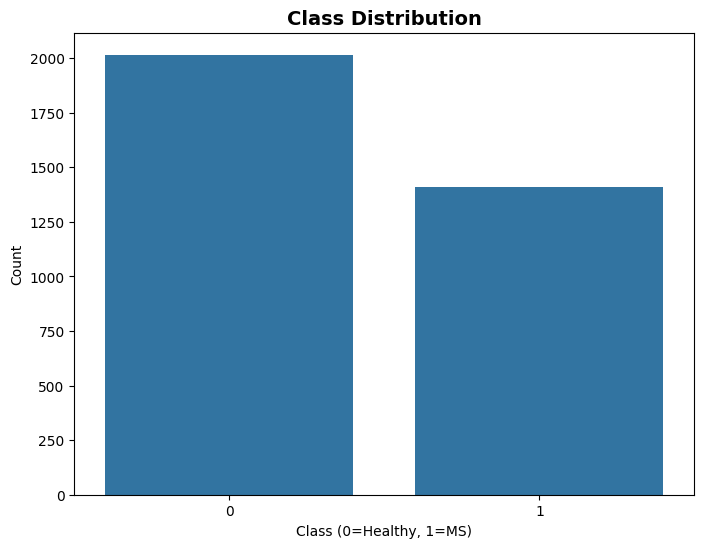

Class 0: 2016 (58.8%)
Class 1: 1411 (41.2%)


In [60]:
plt.figure(figsize=(8, 6))
sns.countplot(x=y)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class (0=Healthy, 1=MS)')
plt.ylabel('Count')
plt.show()

unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f'Class {label}: {count} ({count/len(y)*100:.1f}%)')

### 3.2 Sample Images

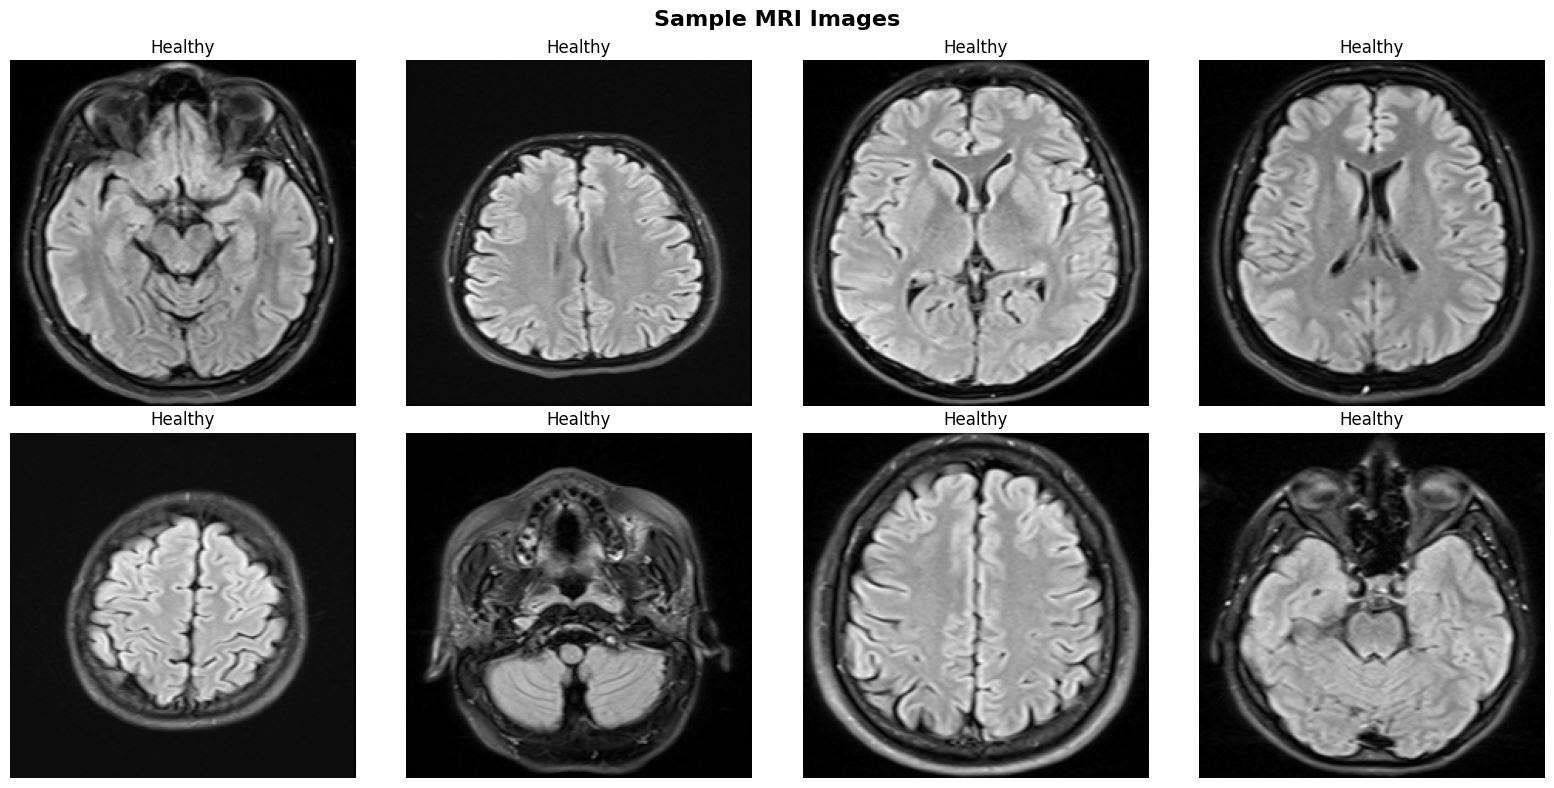

In [61]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample MRI Images', fontsize=16, fontweight='bold')

for i in range(8):
    ax = axes[i//4, i%4]
    ax.imshow(X[i].reshape(224, 224), cmap='gray')
    ax.set_title(f"{'Healthy' if y[i]==0 else 'MS'}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Feature Extraction

### 4.1 LBP Features

In [62]:
def extract_lbp_features(images, P=8, R=1):
    features = []
    for img in images:
        img_reshaped = img.reshape(224, 224)
        lbp = local_binary_pattern(img_reshaped, P, R, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, P+3), range=(0, P+2))
        hist = hist.astype('float')
        hist /= (hist.sum() + 1e-7)
        features.append(hist)
    return np.array(features)

print('Extracting LBP features...')
X_lbp = extract_lbp_features(X)
print(f' LBP shape: {X_lbp.shape}')

Extracting LBP features...
 LBP shape: (3427, 10)


### 4.2 HOG Features

In [63]:
def extract_hog_features(images):
    features = []
    for img in images:
        img_reshaped = img.reshape(224, 224)
        hog_features = hog(img_reshaped, pixels_per_cell=(16, 16),
                          cells_per_block=(2, 2), visualize=False, feature_vector=True)
        features.append(hog_features)
    return np.array(features)

print('Extracting HOG features...')
X_hog = extract_hog_features(X)
print(f' HOG shape: {X_hog.shape}')

Extracting HOG features...
 HOG shape: (3427, 6084)


### 4.3 Combine Features

In [64]:
X_features = np.hstack([X_lbp, X_hog])
print(f' Combined features: {X_features.shape}')
print(f'   LBP: {X_lbp.shape[1]} | HOG: {X_hog.shape[1]} | Total: {X_features.shape[1]}')

 Combined features: (3427, 6094)
   LBP: 10 | HOG: 6084 | Total: 6094


### 4.4 Visualize Features

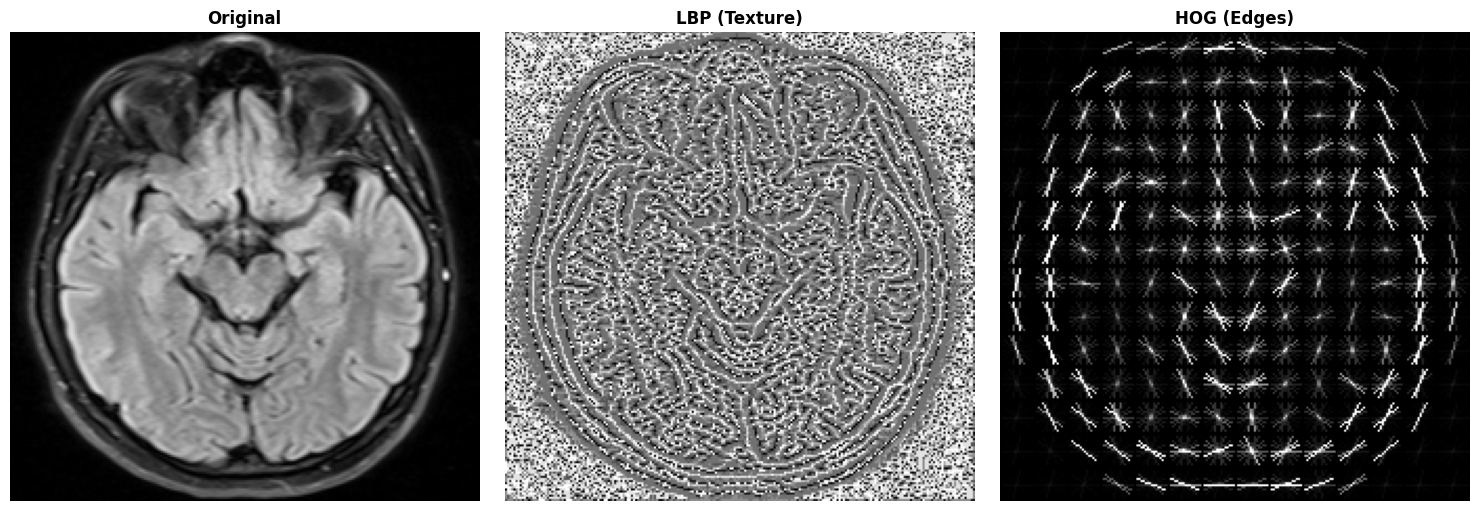

In [65]:
sample_img = X[0].reshape(224, 224)
lbp = local_binary_pattern(sample_img, P=8, R=1, method='uniform')
hog_features, hog_image = hog(sample_img, pixels_per_cell=(16, 16), cells_per_block=(2, 2), visualize=True)
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.imshow(sample_img, cmap='gray')
plt.title('Original', fontweight='bold')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(lbp, cmap='gray')
plt.title('LBP (Texture)', fontweight='bold')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title('HOG (Edges)', fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

## 5. Feature Scaling

In [66]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print(f' Features scaled!')
print(f'   Shape: {X_scaled.shape}')
print(f'   Mean: {X_scaled.mean():.6f}')
print(f'   Std: {X_scaled.std():.6f}')

 Features scaled!
   Shape: (3427, 6094)
   Mean: 0.000000
   Std: 1.000000


## 6. Dimensionality Reduction (PCA)

### 6.1 Variance Analysis

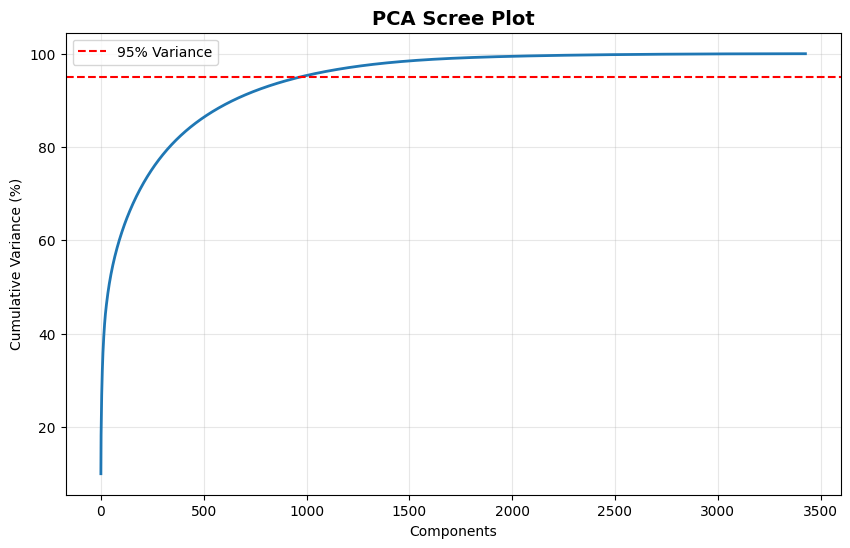

In [67]:
pca_full = PCA().fit(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_)*100, linewidth=2)
plt.xlabel('Components')
plt.ylabel('Cumulative Variance (%)')
plt.title('PCA Scree Plot', fontsize=14, fontweight='bold')
plt.axhline(y=95, color='r', linestyle='--', label='95% Variance')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 6.2 Apply PCA (95% Variance)

In [68]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f' PCA applied!')
print(f'   Original: {X_scaled.shape[1]} → PCA: {X_pca.shape[1]}')
print(f'   Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'   Reduction: {(1 - X_pca.shape[1]/X_scaled.shape[1])*100:.1f}%')

 PCA applied!
   Original: 6094 → PCA: 970
   Variance retained: 95.01%
   Reduction: 84.1%


## 7. Data Splitting (Train / Validation / Test)

In [69]:
# Split 1: Train+Valid (85%) vs Test (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_pca, y, test_size=0.15, random_state=42, stratify=y
)

# Split 2: Train (70%) vs Valid (15%)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, random_state=42, stratify=y_trainval
)

print('='*70)
print('DATA SPLIT SUMMARY')
print('='*70)
print(f'Total: {len(X_pca)}')
print(f'Train:      {len(X_train)} ({len(X_train)/len(X_pca)*100:.1f}%)')
print(f'Validation: {len(X_valid)} ({len(X_valid)/len(X_pca)*100:.1f}%)')
print(f'Test:       {len(X_test)} ({len(X_test)/len(X_pca)*100:.1f}%)')
print('='*70)

# Get original test images for visualization
_, X_test_original, _, _ = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

DATA SPLIT SUMMARY
Total: 3427
Train:      2398 (70.0%)
Validation: 514 (15.0%)
Test:       515 (15.0%)


## 8. Model Training & Evaluation

### 8.1 KNN Model

#### 8.1.1 Hyperparameter Tuning

In [70]:
print('Training KNN...\n')

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_knn.fit(X_train, y_train)

print(f'\n{"="*70}')
print('KNN - BEST PARAMETERS')
print(f'{"="*70}')
print(f'Best params: {grid_knn.best_params_}')
print(f'Best CV score: {grid_knn.best_score_:.4f}')
print(f'{"="*70}')

knn_best = grid_knn.best_estimator_

Training KNN...

Fitting 5 folds for each of 20 candidates, totalling 100 fits

KNN - BEST PARAMETERS
Best params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best CV score: 0.8999


#### 8.1.2 Evaluate on Validation

In [71]:
y_valid_pred_knn = knn_best.predict(X_valid)
valid_acc_knn = accuracy_score(y_valid, y_valid_pred_knn)

print('KNN - Validation:')
print(f'Accuracy: {valid_acc_knn:.4f}')
print('\nReport:')
print(classification_report(y_valid, y_valid_pred_knn, target_names=['Healthy', 'MS']))

KNN - Validation:
Accuracy: 0.9319

Report:
              precision    recall  f1-score   support

     Healthy       0.92      0.97      0.94       302
          MS       0.96      0.87      0.91       212

    accuracy                           0.93       514
   macro avg       0.94      0.92      0.93       514
weighted avg       0.93      0.93      0.93       514



#### 8.1.3 Evaluate on Test

In [72]:
y_test_pred_knn = knn_best.predict(X_test)
test_acc_knn = accuracy_score(y_test, y_test_pred_knn)

print('='*70)
print('KNN - TEST SET')
print('='*70)
print(f'Accuracy: {test_acc_knn:.4f}')
print('\nReport:')
print(classification_report(y_test, y_test_pred_knn, target_names=['Healthy', 'MS']))
print('='*70)

KNN - TEST SET
Accuracy: 0.9340

Report:
              precision    recall  f1-score   support

     Healthy       0.92      0.97      0.95       303
          MS       0.95      0.89      0.92       212

    accuracy                           0.93       515
   macro avg       0.94      0.93      0.93       515
weighted avg       0.93      0.93      0.93       515



#### 8.1.4 Confusion Matrix

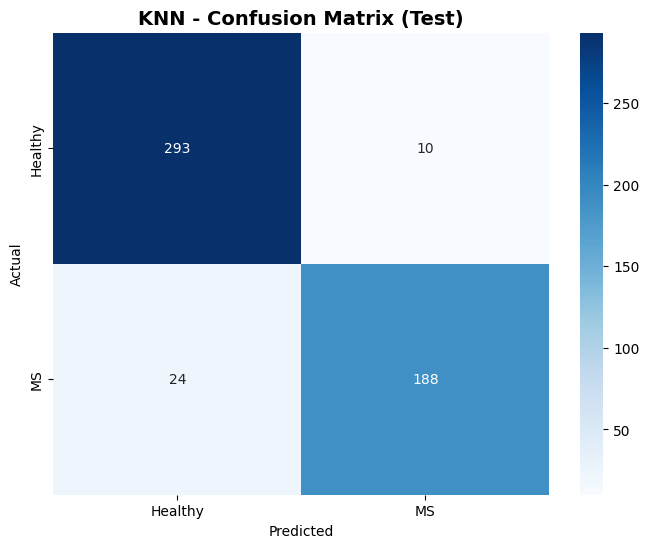

In [73]:
cm_knn = confusion_matrix(y_test, y_test_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'MS'], yticklabels=['Healthy', 'MS'])
plt.title('KNN - Confusion Matrix (Test)', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 8.2 SVM Model

#### 8.2.1 Hyperparameter Tuning

In [74]:
print('Training SVM...\n')

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'linear']
}

svm = SVC(probability=True, random_state=42)
grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_svm.fit(X_train, y_train)

print(f'\n{"="*70}')
print('SVM - BEST PARAMETERS')
print(f'{"="*70}')
print(f'Best params: {grid_svm.best_params_}')
print(f'Best CV score: {grid_svm.best_score_:.4f}')
print(f'{"="*70}')

svm_best = grid_svm.best_estimator_

Training SVM...

Fitting 5 folds for each of 32 candidates, totalling 160 fits

SVM - BEST PARAMETERS
Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score: 0.9229


#### 8.2.2 Evaluate on Validation

In [75]:
y_valid_pred_svm = svm_best.predict(X_valid)
valid_acc_svm = accuracy_score(y_valid, y_valid_pred_svm)

print('SVM - Validation:')
print(f'Accuracy: {valid_acc_svm:.4f}')
print('\nReport:')
print(classification_report(y_valid, y_valid_pred_svm, target_names=['Healthy', 'MS']))

SVM - Validation:
Accuracy: 0.9280

Report:
              precision    recall  f1-score   support

     Healthy       0.93      0.95      0.94       302
          MS       0.93      0.90      0.91       212

    accuracy                           0.93       514
   macro avg       0.93      0.92      0.93       514
weighted avg       0.93      0.93      0.93       514



#### 8.2.3 Evaluate on Test

In [76]:
y_test_pred_svm = svm_best.predict(X_test)
test_acc_svm = accuracy_score(y_test, y_test_pred_svm)

print('='*70)
print('SVM - TEST SET')
print('='*70)
print(f'Accuracy: {test_acc_svm:.4f}')
print('\nReport:')
print(classification_report(y_test, y_test_pred_svm, target_names=['Healthy', 'MS']))
print('='*70)

SVM - TEST SET
Accuracy: 0.9359

Report:
              precision    recall  f1-score   support

     Healthy       0.92      0.98      0.95       303
          MS       0.97      0.87      0.92       212

    accuracy                           0.94       515
   macro avg       0.94      0.93      0.93       515
weighted avg       0.94      0.94      0.94       515



#### 8.2.4 Confusion Matrix

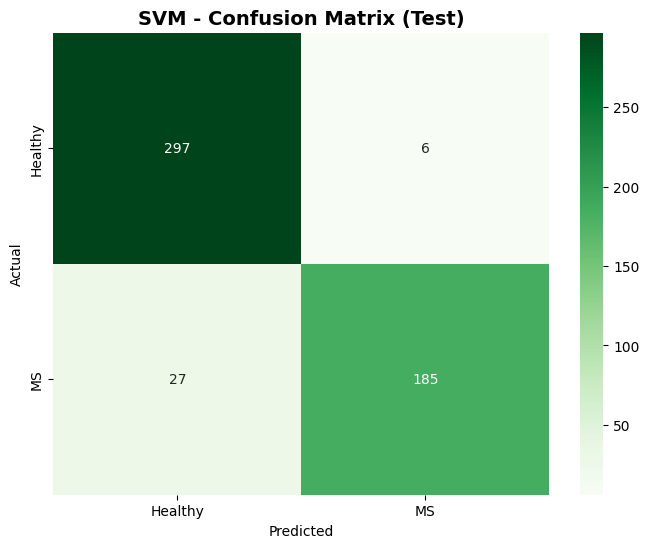

In [77]:
cm_svm = confusion_matrix(y_test, y_test_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'MS'], yticklabels=['Healthy', 'MS'])
plt.title('SVM - Confusion Matrix (Test)', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 8.3 Voting Classifier

#### 8.3.1 Train Ensemble

In [78]:
print('Training Voting Classifier...\n')

voting_clf = VotingClassifier(
    estimators=[('knn', knn_best), ('svm', svm_best)],
    voting='soft'
)

voting_clf.fit(X_train, y_train)
print('Voting Classifier trained!')

Training Voting Classifier...

Voting Classifier trained!


#### 8.3.2 Evaluate on Validation

In [79]:
y_valid_pred_voting = voting_clf.predict(X_valid)
valid_acc_voting = accuracy_score(y_valid, y_valid_pred_voting)

print('Voting - Validation:')
print(f'Accuracy: {valid_acc_voting:.4f}')
print('\nReport:')
print(classification_report(y_valid, y_valid_pred_voting, target_names=['Healthy', 'MS']))

Voting - Validation:
Accuracy: 0.9514

Report:
              precision    recall  f1-score   support

     Healthy       0.94      0.98      0.96       302
          MS       0.97      0.92      0.94       212

    accuracy                           0.95       514
   macro avg       0.95      0.95      0.95       514
weighted avg       0.95      0.95      0.95       514



#### 8.3.3 Evaluate on Test

In [80]:
y_test_pred_voting = voting_clf.predict(X_test)
test_acc_voting = accuracy_score(y_test, y_test_pred_voting)

print('='*70)
print('VOTING CLASSIFIER - TEST SET')
print('='*70)
print(f'Accuracy: {test_acc_voting:.4f}')
print('\nReport:')
print(classification_report(y_test, y_test_pred_voting, target_names=['Healthy', 'MS']))
print('='*70)

VOTING CLASSIFIER - TEST SET
Accuracy: 0.9417

Report:
              precision    recall  f1-score   support

     Healthy       0.93      0.98      0.95       303
          MS       0.97      0.89      0.93       212

    accuracy                           0.94       515
   macro avg       0.95      0.93      0.94       515
weighted avg       0.94      0.94      0.94       515



#### 8.3.4 Confusion Matrix

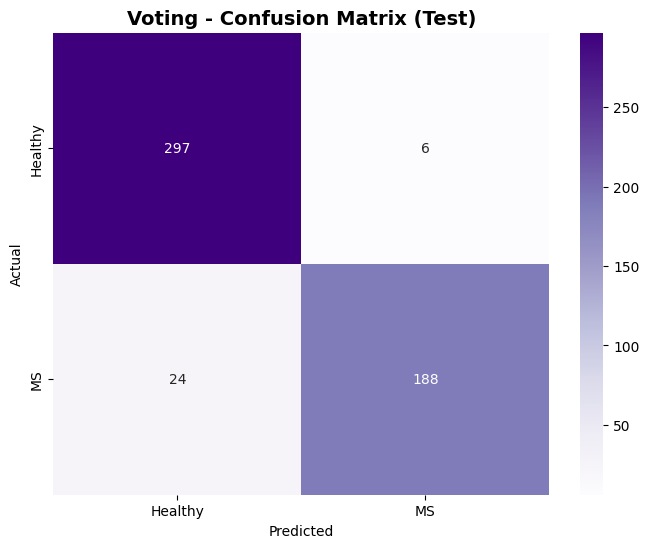

In [81]:
cm_voting = confusion_matrix(y_test, y_test_pred_voting)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_voting, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Healthy', 'MS'], yticklabels=['Healthy', 'MS'])
plt.title('Voting - Confusion Matrix (Test)', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 8.4 Model Comparison (Train / Valid / Test)

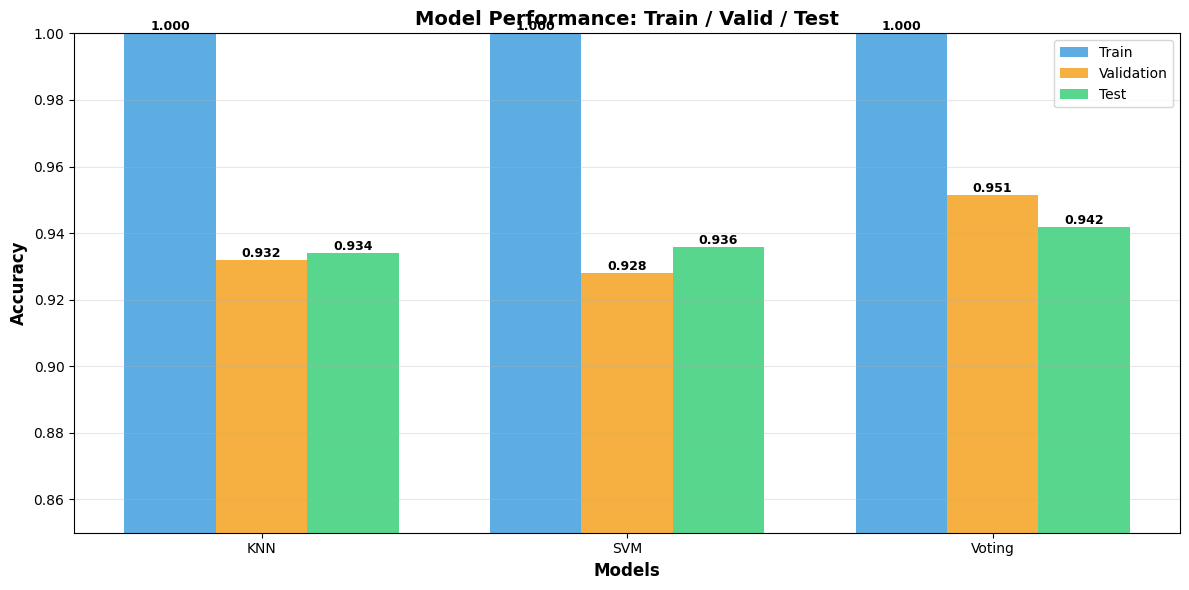


MODEL PERFORMANCE SUMMARY
Model                Train        Validation   Test        
----------------------------------------------------------------------
KNN                  1.0000       0.9319       0.9340
SVM                  1.0000       0.9280       0.9359
Voting               1.0000       0.9514       0.9417


In [82]:
train_acc_knn = accuracy_score(y_train, knn_best.predict(X_train))
train_acc_svm = accuracy_score(y_train, svm_best.predict(X_train))
train_acc_voting = accuracy_score(y_train, voting_clf.predict(X_train))

models = ['KNN', 'SVM', 'Voting']
train_scores = [train_acc_knn, train_acc_svm, train_acc_voting]
valid_scores = [valid_acc_knn, valid_acc_svm, valid_acc_voting]
test_scores = [test_acc_knn, test_acc_svm, test_acc_voting]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, train_scores, width, label='Train', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, valid_scores, width, label='Validation', color='#f39c12', alpha=0.8)
bars3 = ax.bar(x + width, test_scores, width, label='Test', color='#2ecc71', alpha=0.8)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Performance: Train / Valid / Test', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.85, 1.0)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n' + '='*70)
print('MODEL PERFORMANCE SUMMARY')
print('='*70)
print(f'{"Model":<20} {"Train":<12} {"Validation":<12} {"Test":<12}')
print('-'*70)
for model, train, valid, test in zip(models, train_scores, valid_scores, test_scores):
    print(f'{model:<20} {train:.4f}       {valid:.4f}       {test:.4f}')
print('='*70)

## 9. Advanced Analysis

### 9.1 Cross-Validation (10-Fold)

CROSS VALIDATION (10-Fold)

1. KNN:
--------------------------------------------------
CV Scores: [0.88921283 0.86297376 0.88921283 0.90670554 0.88629738 0.95918367
 0.96209913 0.95614035 0.96783626 0.97368421]
Mean: 0.9253 ± 0.0399
Range: [0.8630, 0.9737]

2. SVM:
--------------------------------------------------
CV Scores: [0.89212828 0.89504373 0.90087464 0.93586006 0.90670554 0.95335277
 0.97084548 0.97076023 0.95906433 0.95906433]
Mean: 0.9344 ± 0.0307
Range: [0.8921, 0.9708]

3. Voting:
--------------------------------------------------
CV Scores: [0.90087464 0.90087464 0.90670554 0.94169096 0.91836735 0.95918367
 0.97084548 0.96783626 0.97660819 0.97368421]
Mean: 0.9417 ± 0.0303
Range: [0.9009, 0.9766]



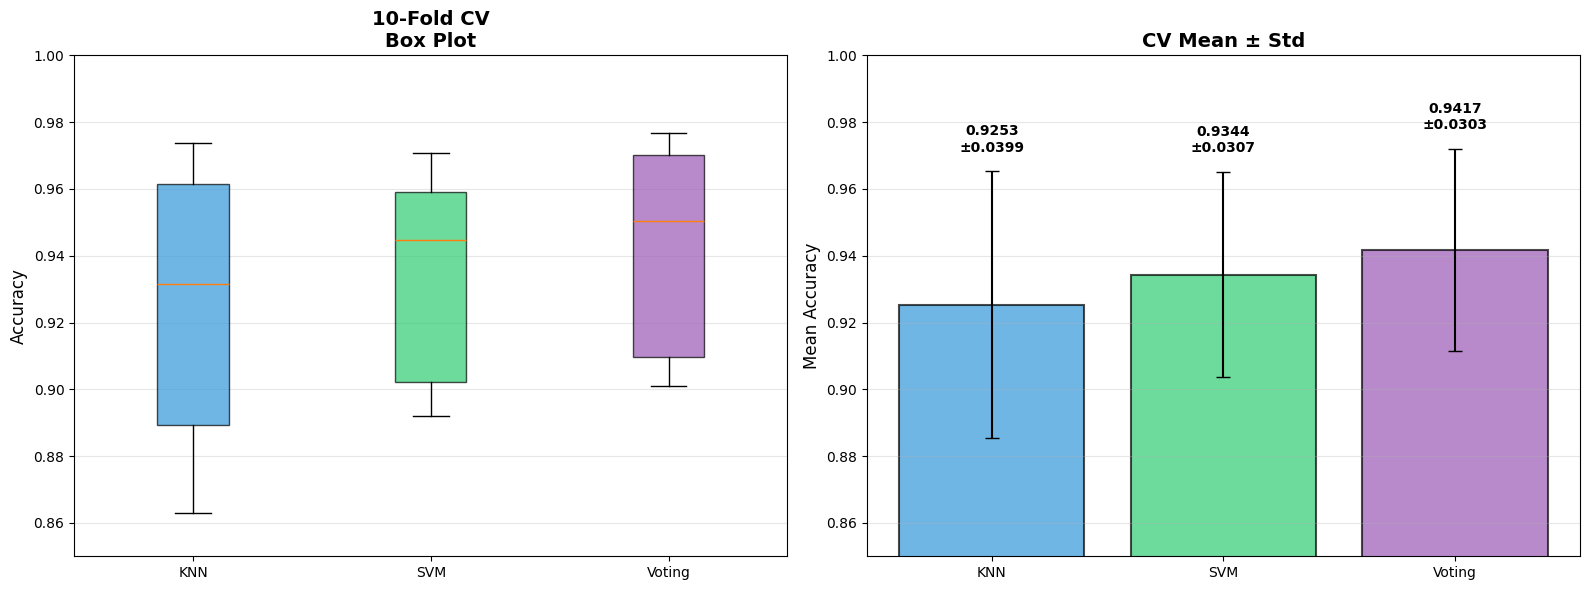

In [83]:
cv_folds = 10

print('='*70)
print('CROSS VALIDATION (10-Fold)')
print('='*70)

# KNN
print('\n1. KNN:')
print('-'*50)
cv_scores_knn = cross_val_score(knn_best, X_pca, y, cv=cv_folds, scoring='accuracy')
print(f'CV Scores: {cv_scores_knn}')
print(f'Mean: {cv_scores_knn.mean():.4f} ± {cv_scores_knn.std():.4f}')
print(f'Range: [{cv_scores_knn.min():.4f}, {cv_scores_knn.max():.4f}]')

# SVM
print('\n2. SVM:')
print('-'*50)
cv_scores_svm = cross_val_score(svm_best, X_pca, y, cv=cv_folds, scoring='accuracy')
print(f'CV Scores: {cv_scores_svm}')
print(f'Mean: {cv_scores_svm.mean():.4f} ± {cv_scores_svm.std():.4f}')
print(f'Range: [{cv_scores_svm.min():.4f}, {cv_scores_svm.max():.4f}]')

# Voting
print('\n3. Voting:')
print('-'*50)
cv_scores_voting = cross_val_score(voting_clf, X_pca, y, cv=cv_folds, scoring='accuracy')
print(f'CV Scores: {cv_scores_voting}')
print(f'Mean: {cv_scores_voting.mean():.4f} ± {cv_scores_voting.std():.4f}')
print(f'Range: [{cv_scores_voting.min():.4f}, {cv_scores_voting.max():.4f}]')

print('\n' + '='*70)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
ax1 = axes[0]
cv_data = [cv_scores_knn, cv_scores_svm, cv_scores_voting]
bp = ax1.boxplot(cv_data, labels=['KNN', 'SVM', 'Voting'], patch_artist=True)
colors = ['#3498db', '#2ecc71', '#9b59b6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('10-Fold CV\nBox Plot', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0.85, 1.0)

# Bar plot
ax2 = axes[1]
means = [cv_scores_knn.mean(), cv_scores_svm.mean(), cv_scores_voting.mean()]
stds = [cv_scores_knn.std(), cv_scores_svm.std(), cv_scores_voting.std()]
bars = ax2.bar(['KNN', 'SVM', 'Voting'], means, yerr=stds, capsize=5,
               color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Mean Accuracy', fontsize=12)
ax2.set_title('CV Mean ± Std', fontsize=14, fontweight='bold')
ax2.set_ylim(0.85, 1.0)
ax2.grid(axis='y', alpha=0.3)

for i, (mean, std) in enumerate(zip(means, stds)):
    ax2.text(i, mean + std + 0.005, f'{mean:.4f}\n±{std:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 9.2 Learning Curves (Overfitting Detection)

Computing learning curve for KNN...
Computing learning curve for SVM...
Computing learning curve for Voting...


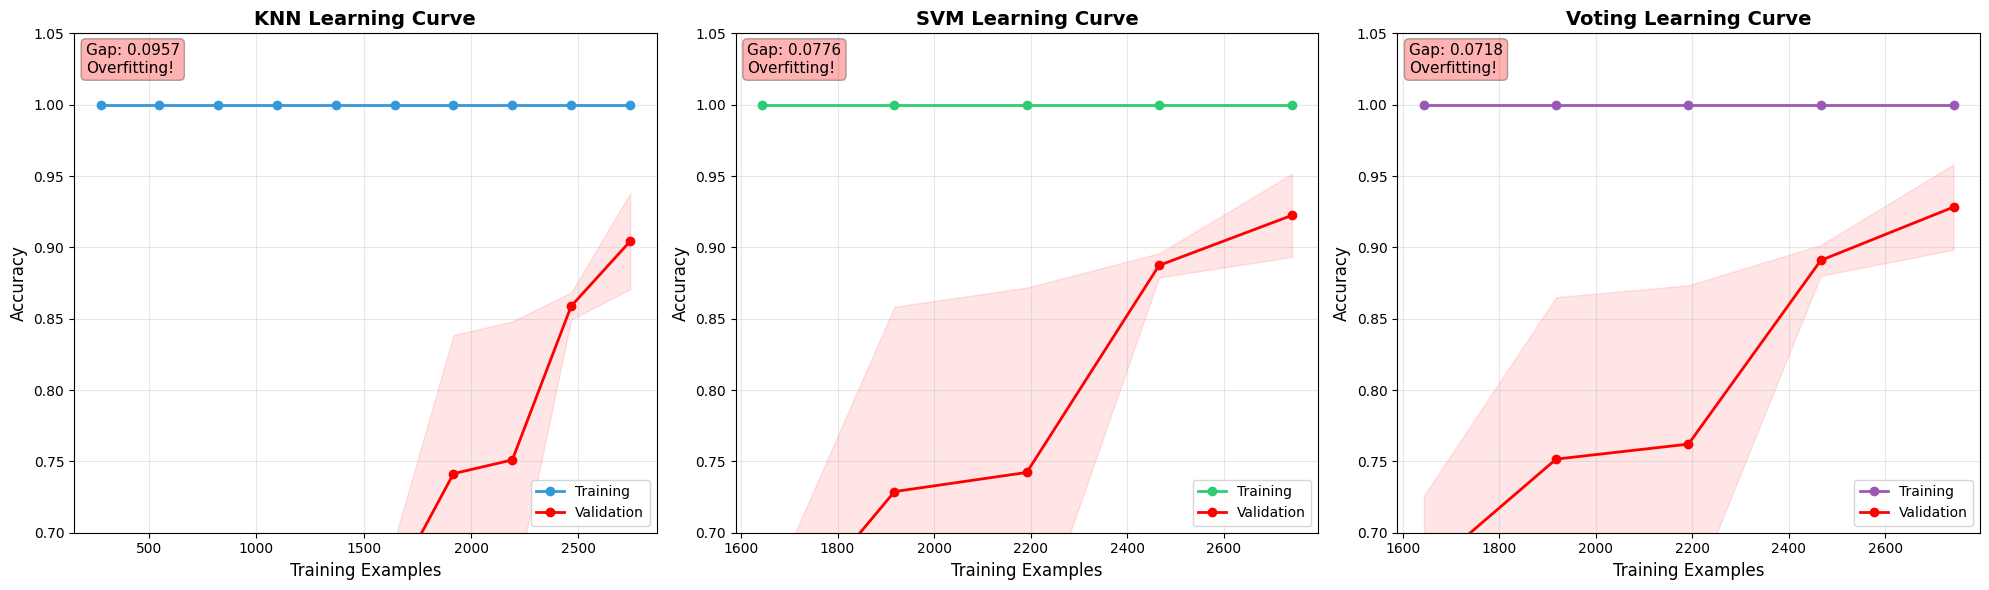


LEARNING CURVE INTERPRETATION
Gap < 2%:  Excellent generalization
Gap 2-5%:  Slight overfitting
Gap > 5%:  Overfitting detected


In [84]:
def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy', random_state=42
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    return train_sizes, train_mean, train_std, test_mean, test_std

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
models_to_plot = [(knn_best, 'KNN', '#3498db'), (svm_best, 'SVM', '#2ecc71'), (voting_clf, 'Voting', '#9b59b6')]

for idx, (model, name, color) in enumerate(models_to_plot):
    ax = axes[idx]
    print(f'Computing learning curve for {name}...')
    train_sizes, train_mean, train_std, test_mean, test_std = plot_learning_curve(model, name, X_pca, y, cv=5)
    
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color=color)
    ax.plot(train_sizes, train_mean, 'o-', color=color, label='Training', linewidth=2)
    
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
    ax.plot(train_sizes, test_mean, 'o-', color='red', label='Validation', linewidth=2)
    
    ax.set_title(f'{name} Learning Curve', fontsize=14, fontweight='bold')
    ax.set_xlabel('Training Examples', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_ylim(0.7, 1.05)
    
    final_gap = train_mean[-1] - test_mean[-1]
    if final_gap > 0.05:
        status, status_color = 'Overfitting!', 'red'
    elif final_gap < 0.02:
        status, status_color = 'Good Fit', 'green'
    else:
        status, status_color = 'Slight Overfitting', 'orange'
    
    ax.text(0.02, 0.98, f'Gap: {final_gap:.4f}\n{status}',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor=status_color, alpha=0.3))

plt.tight_layout()
plt.show()

print('\n' + '='*70)
print('LEARNING CURVE INTERPRETATION')
print('='*70)
print('Gap < 2%:  Excellent generalization')
print('Gap 2-5%:  Slight overfitting')
print('Gap > 5%:  Overfitting detected')
print('='*70)

### 9.3 ROC Curves

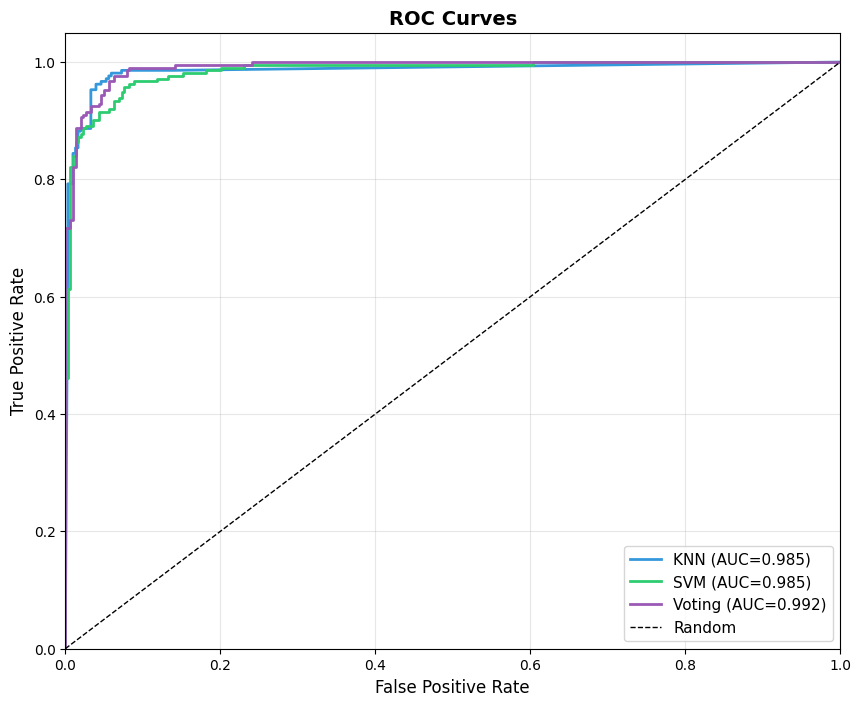

In [85]:
plt.figure(figsize=(10, 8))

# KNN
y_pred_proba_knn = knn_best.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC={roc_auc_knn:.3f})', linewidth=2, color='#3498db')

# SVM
y_pred_proba_svm = svm_best.predict_proba(X_test)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC={roc_auc_svm:.3f})', linewidth=2, color='#2ecc71')

# Voting
y_pred_proba_voting = voting_clf.predict_proba(X_test)[:, 1]
fpr_voting, tpr_voting, _ = roc_curve(y_test, y_pred_proba_voting)
roc_auc_voting = auc(fpr_voting, tpr_voting)
plt.plot(fpr_voting, tpr_voting, label=f'Voting (AUC={roc_auc_voting:.3f})', linewidth=2, color='#9b59b6')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.show()

## 10. Detailed Error Analysis

### 10.1 Confusion Matrix Breakdown (FP, FN, TP, TN)

In [86]:
def analyze_confusion_matrix(cm, model_name):
    TN, FP, FN, TP = cm.ravel()
    total = TN + FP + FN + TP
    accuracy = (TP + TN) / total
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    fnr = FN / (FN + TP) if (FN + TP) > 0 else 0
    
    print(f'\n{"="*70}')
    print(f'{model_name.upper()} - CONFUSION MATRIX ANALYSIS')
    print(f'{"="*70}')
    
    print(f'\n Components:')
    print(f'├─ TN:  {TN:4d} - Correctly identified Healthy')
    print(f'├─ FP:  {FP:4d} - Healthy wrongly as MS ')
    print(f'├─ FN:  {FN:4d} - MS wrongly as Healthy  CRITICAL!')
    print(f'└─ TP:  {TP:4d} - Correctly identified MS')
    
    print(f'\n  Error Rates:')
    print(f'├─ FPR: {fpr:.4f} ({fpr*100:.2f}%) - Type I Error')
    print(f'│   → {FP} healthy patients misdiagnosed as MS')
    print(f'└─ FNR: {fnr:.4f} ({fnr*100:.2f}%) - Type II Error')
    print(f'    → {FN} MS patients MISSED!')
    
    if fnr > fpr:
        print(f'\n  WARNING: FNR > FPR - Missing sick patients!')
    else:
        print(f'\n✓ FPR > FNR - Better outcome')
    
    print(f'{"="*70}')
    return {'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP, 'FPR': fpr, 'FNR': fnr, 'accuracy': accuracy}

print(' DETAILED ERROR ANALYSIS\n')
knn_analysis = analyze_confusion_matrix(cm_knn, 'KNN')
svm_analysis = analyze_confusion_matrix(cm_svm, 'SVM')
voting_analysis = analyze_confusion_matrix(cm_voting, 'Voting')

 DETAILED ERROR ANALYSIS


KNN - CONFUSION MATRIX ANALYSIS

 Components:
├─ TN:   293 - Correctly identified Healthy
├─ FP:    10 - Healthy wrongly as MS 
├─ FN:    24 - MS wrongly as Healthy  CRITICAL!
└─ TP:   188 - Correctly identified MS

  Error Rates:
├─ FPR: 0.0330 (3.30%) - Type I Error
│   → 10 healthy patients misdiagnosed as MS
└─ FNR: 0.1132 (11.32%) - Type II Error
    → 24 MS patients MISSED!


SVM - CONFUSION MATRIX ANALYSIS

 Components:
├─ TN:   297 - Correctly identified Healthy
├─ FP:     6 - Healthy wrongly as MS 
├─ FN:    27 - MS wrongly as Healthy  CRITICAL!
└─ TP:   185 - Correctly identified MS

  Error Rates:
├─ FPR: 0.0198 (1.98%) - Type I Error
│   → 6 healthy patients misdiagnosed as MS
└─ FNR: 0.1274 (12.74%) - Type II Error
    → 27 MS patients MISSED!


VOTING - CONFUSION MATRIX ANALYSIS

 Components:
├─ TN:   297 - Correctly identified Healthy
├─ FP:     6 - Healthy wrongly as MS 
├─ FN:    24 - MS wrongly as Healthy  CRITICAL!
└─ TP:   188 - Correctly 

### 10.2 Visualize Misclassified Images

 VISUALIZING ERRORS


KNN - MISCLASSIFICATIONS
FP: 10 (Healthy → MS)
FN: 24 (MS → Healthy)



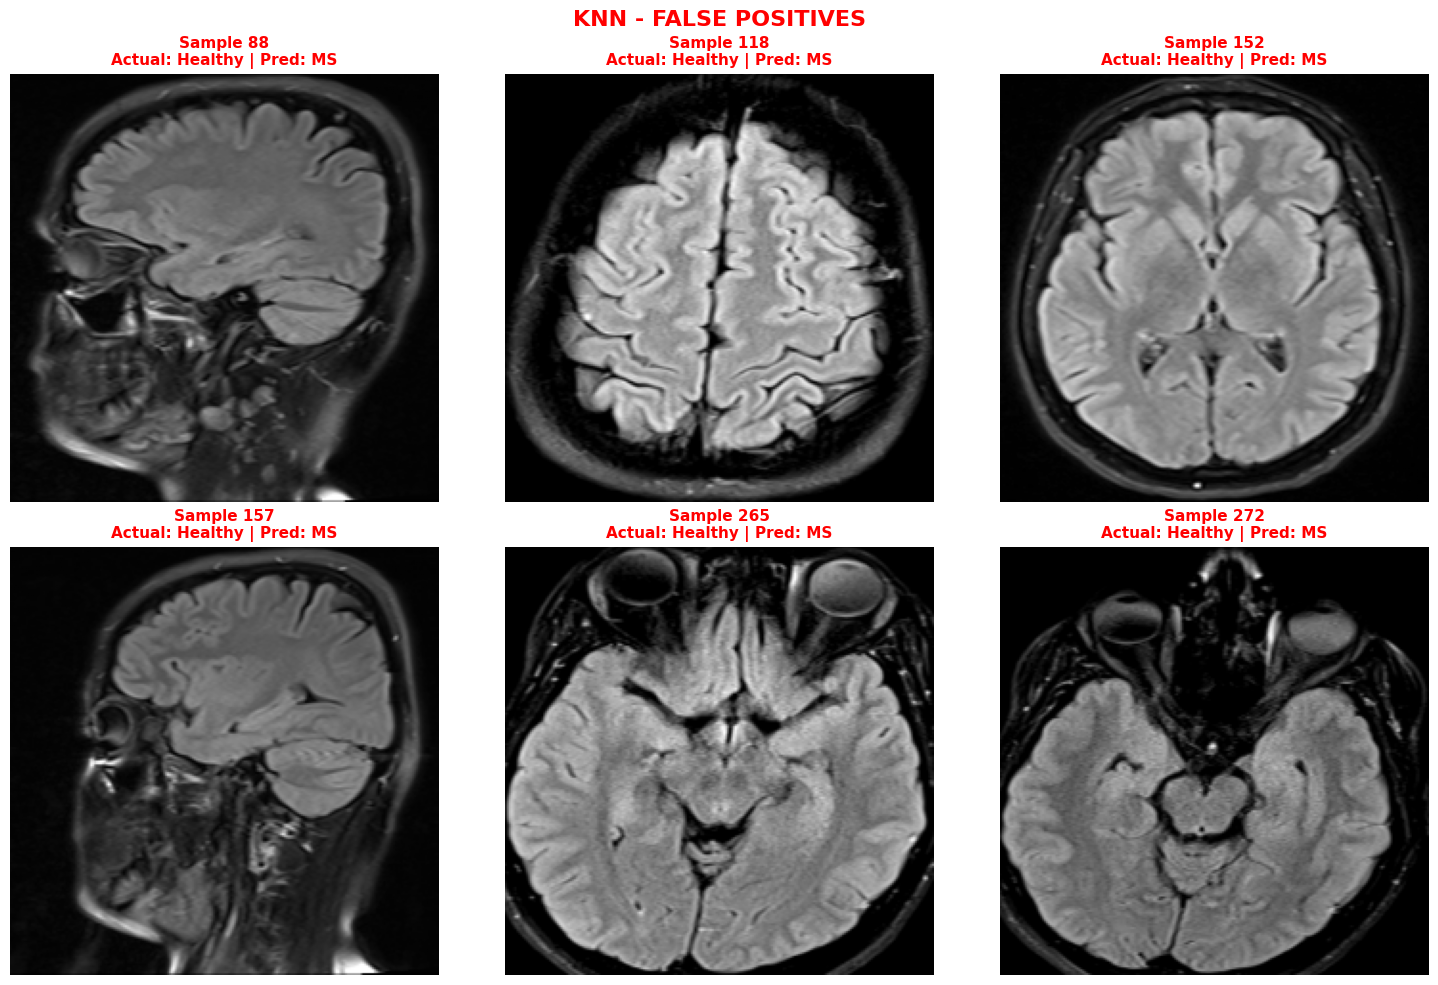

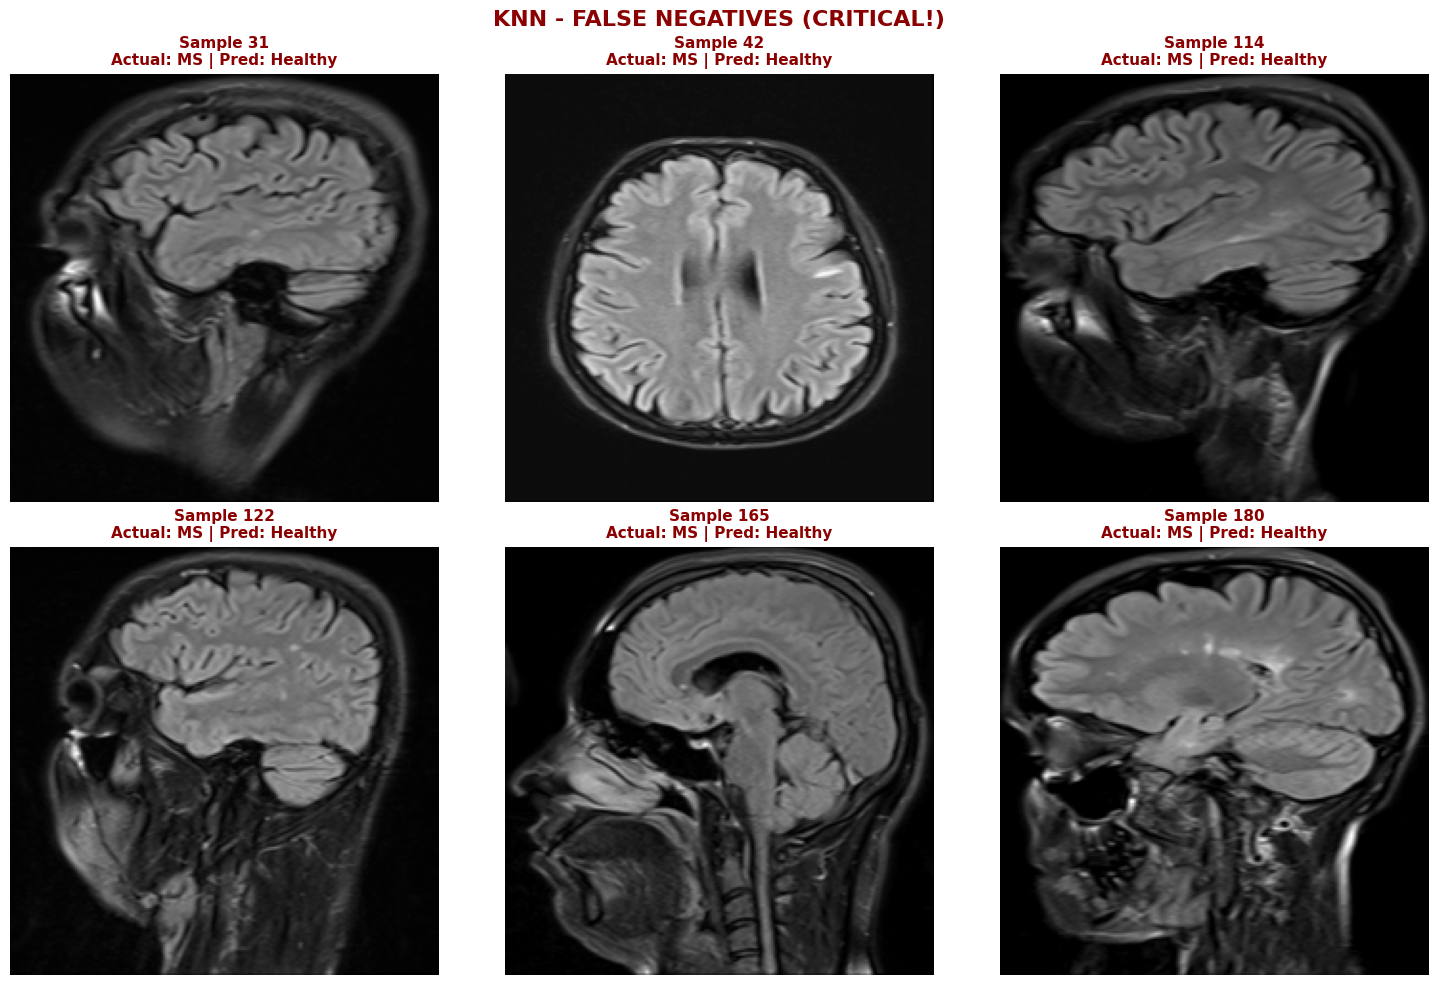


SVM - MISCLASSIFICATIONS
FP: 6 (Healthy → MS)
FN: 27 (MS → Healthy)



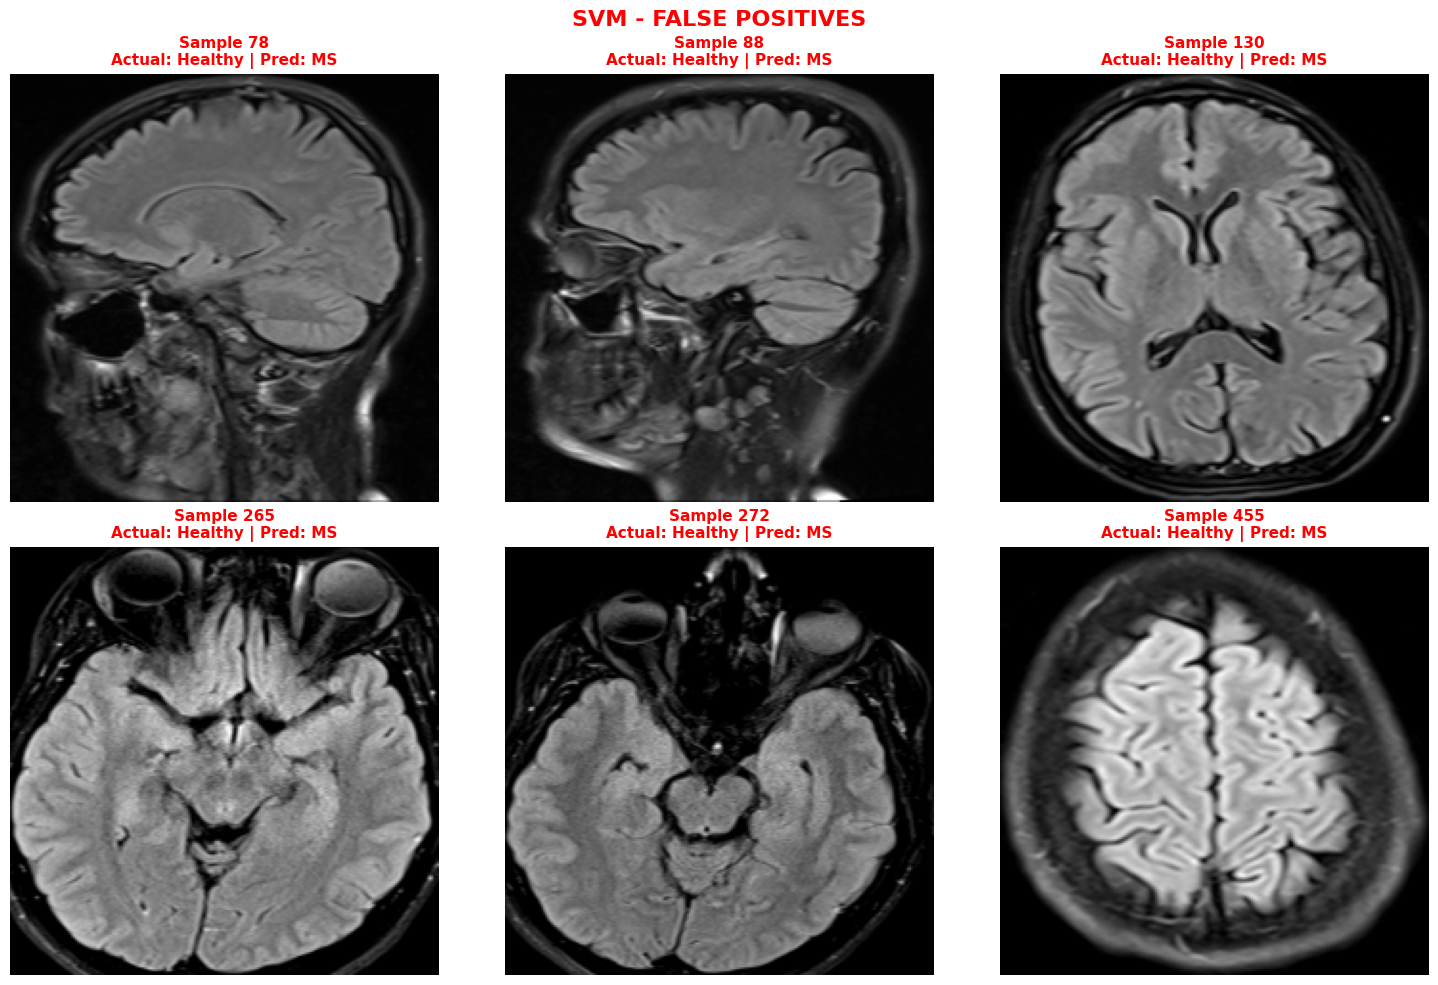

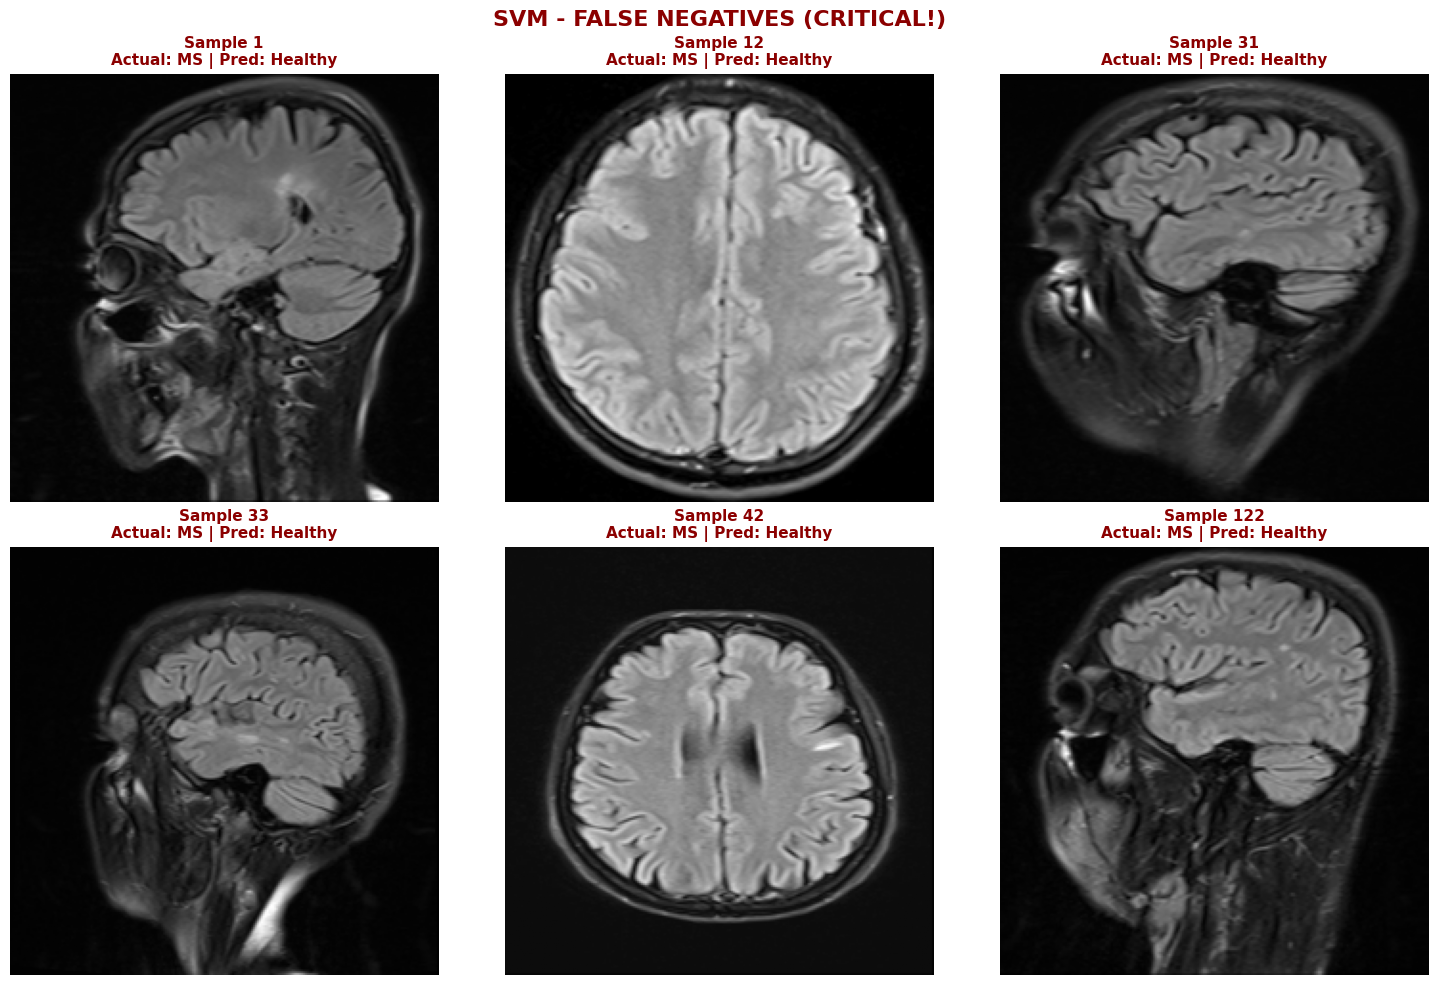


VOTING - MISCLASSIFICATIONS
FP: 6 (Healthy → MS)
FN: 24 (MS → Healthy)



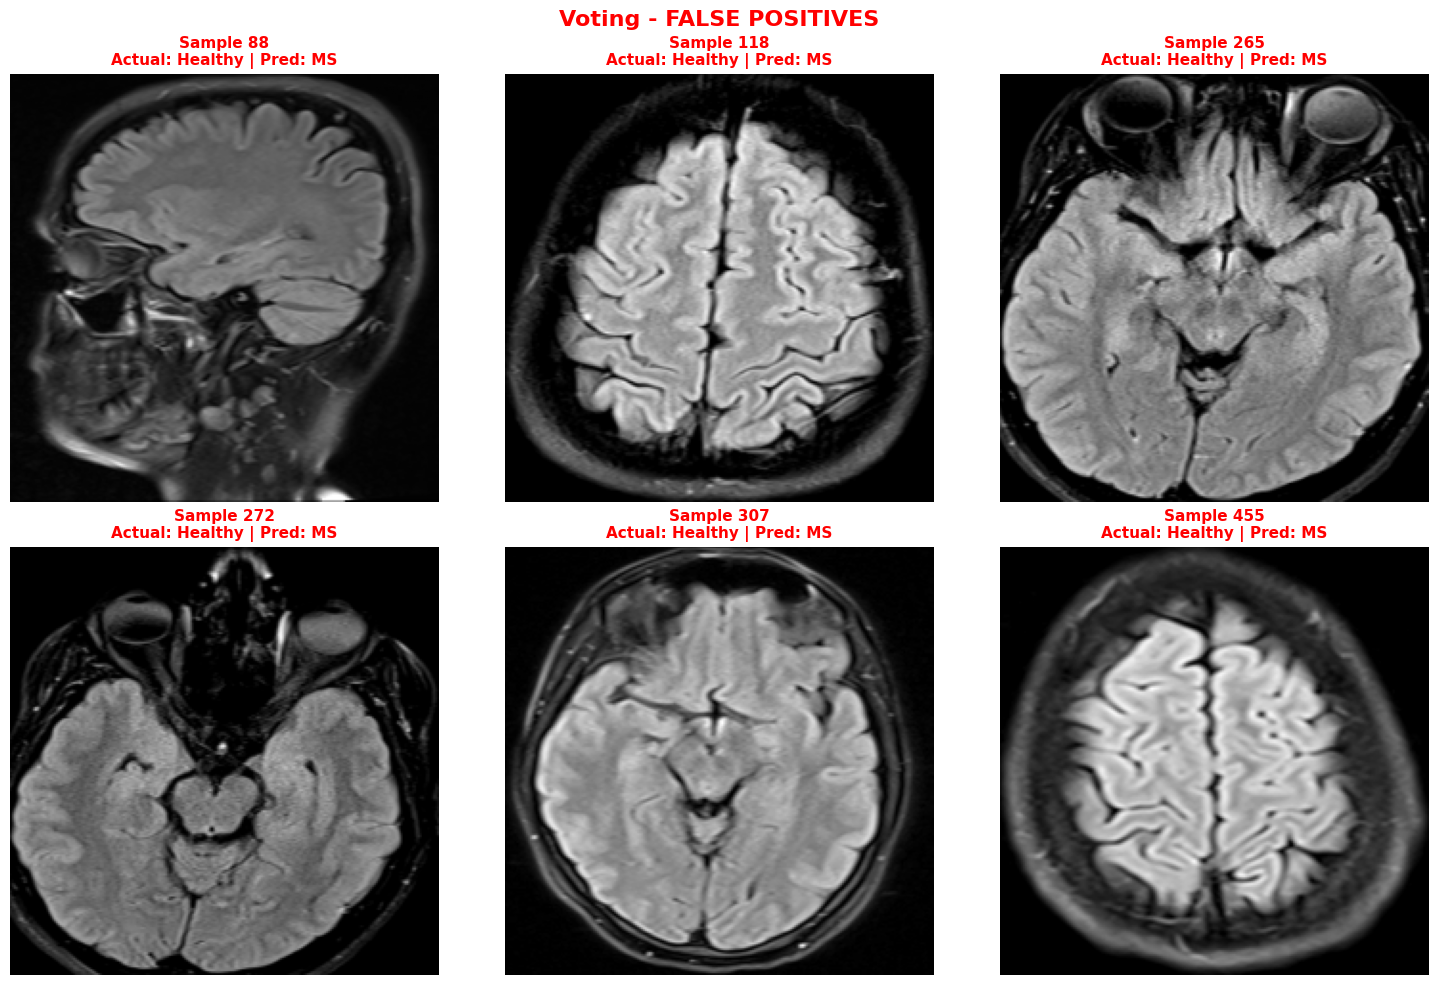

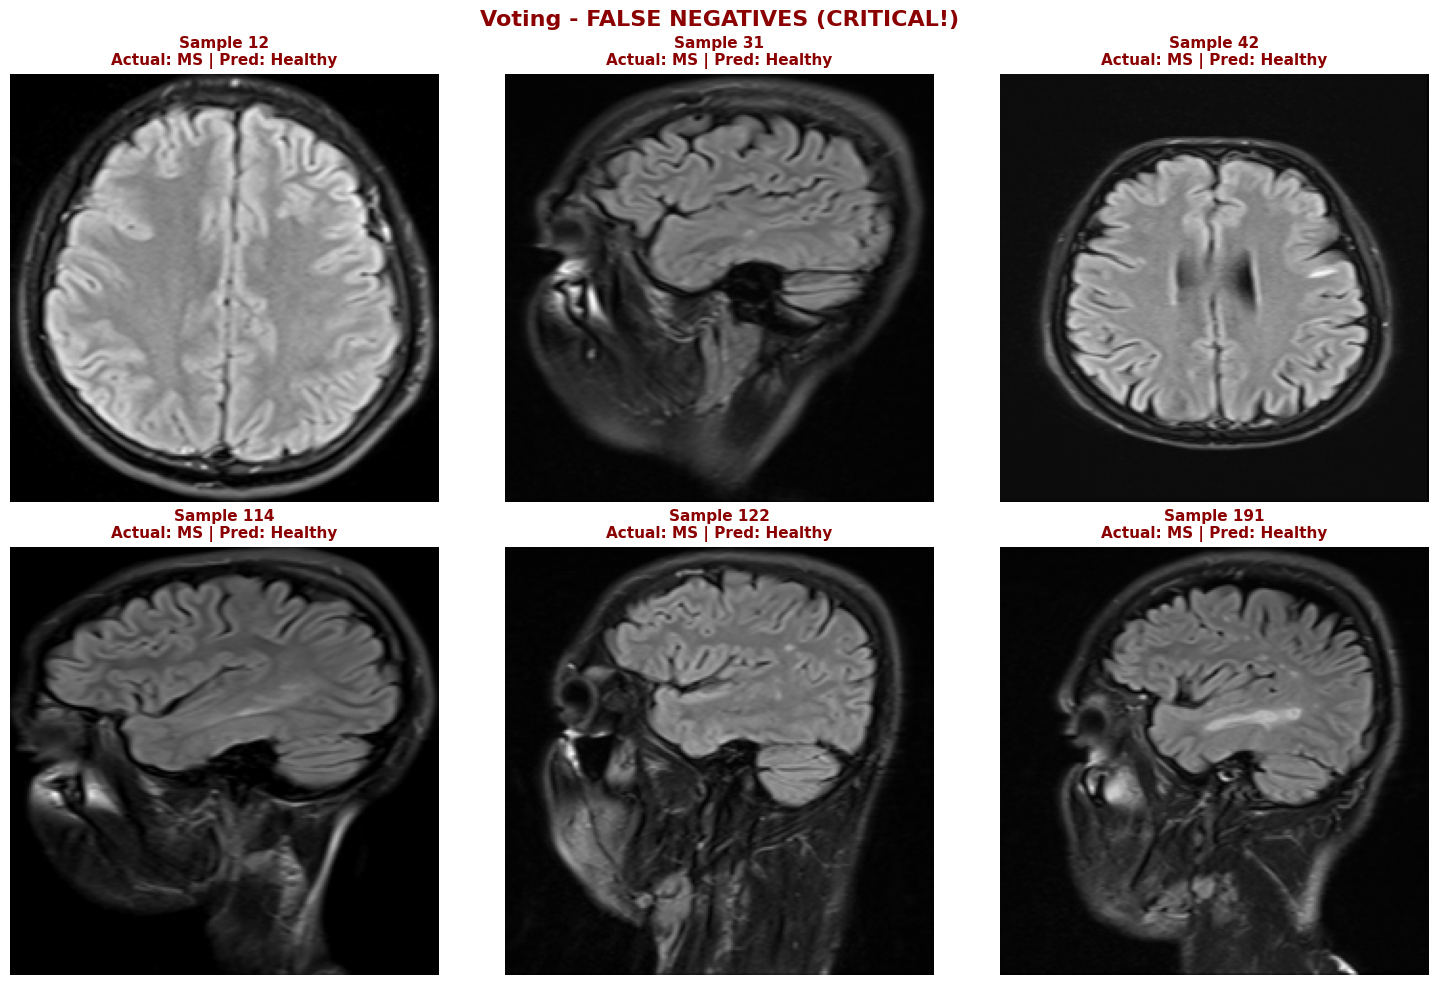

In [87]:
def visualize_errors(model, model_name, X_test, y_test, X_test_original):
    y_pred = model.predict(X_test)
    fp_idx = np.where((y_pred == 1) & (y_test == 0))[0]
    fn_idx = np.where((y_pred == 0) & (y_test == 1))[0]
    
    print(f'\n{"="*70}')
    print(f'{model_name.upper()} - MISCLASSIFICATIONS')
    print(f'{"="*70}')
    print(f'FP: {len(fp_idx)} (Healthy → MS)')
    print(f'FN: {len(fn_idx)} (MS → Healthy)')
    print(f'{"="*70}\n')
    
    # FP
    if len(fp_idx) > 0:
        n_fp = min(6, len(fp_idx))
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(f'{model_name} - FALSE POSITIVES', fontsize=16, fontweight='bold', color='red')
        for i in range(6):
            ax = axes[i // 3, i % 3]
            if i < n_fp:
                idx = fp_idx[i]
                img = X_test_original[idx].reshape(224, 224)
                ax.imshow(img, cmap='gray')
                ax.set_title(f'Sample {idx}\nActual: Healthy | Pred: MS', fontsize=11, color='red', fontweight='bold')
                ax.axis('off')
            else:
                ax.axis('off')
        plt.tight_layout()
        plt.show()
    
    # FN
    if len(fn_idx) > 0:
        n_fn = min(6, len(fn_idx))
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(f'{model_name} - FALSE NEGATIVES (CRITICAL!)', fontsize=16, fontweight='bold', color='darkred')
        for i in range(6):
            ax = axes[i // 3, i % 3]
            if i < n_fn:
                idx = fn_idx[i]
                img = X_test_original[idx].reshape(224, 224)
                ax.imshow(img, cmap='gray')
                ax.set_title(f'Sample {idx}\nActual: MS | Pred: Healthy', fontsize=11, color='darkred', fontweight='bold')
                ax.axis('off')
            else:
                ax.axis('off')
        plt.tight_layout()
        plt.show()
    
    return fp_idx, fn_idx

print(' VISUALIZING ERRORS\n')
knn_fp, knn_fn = visualize_errors(knn_best, 'KNN', X_test, y_test, X_test_original)
svm_fp, svm_fn = visualize_errors(svm_best, 'SVM', X_test, y_test, X_test_original)
voting_fp, voting_fn = visualize_errors(voting_clf, 'Voting', X_test, y_test, X_test_original)

### 10.4 Common Hard Cases

ERROR PATTERN ANALYSIS

 Error Overlap:
├─ All 3 wrong (hardest):   19 images
├─ Only KNN wrong:          11 images
├─ Only SVM wrong:           7 images
└─ Only Voting wrong:        0 images

 Hardest cases (all failed)



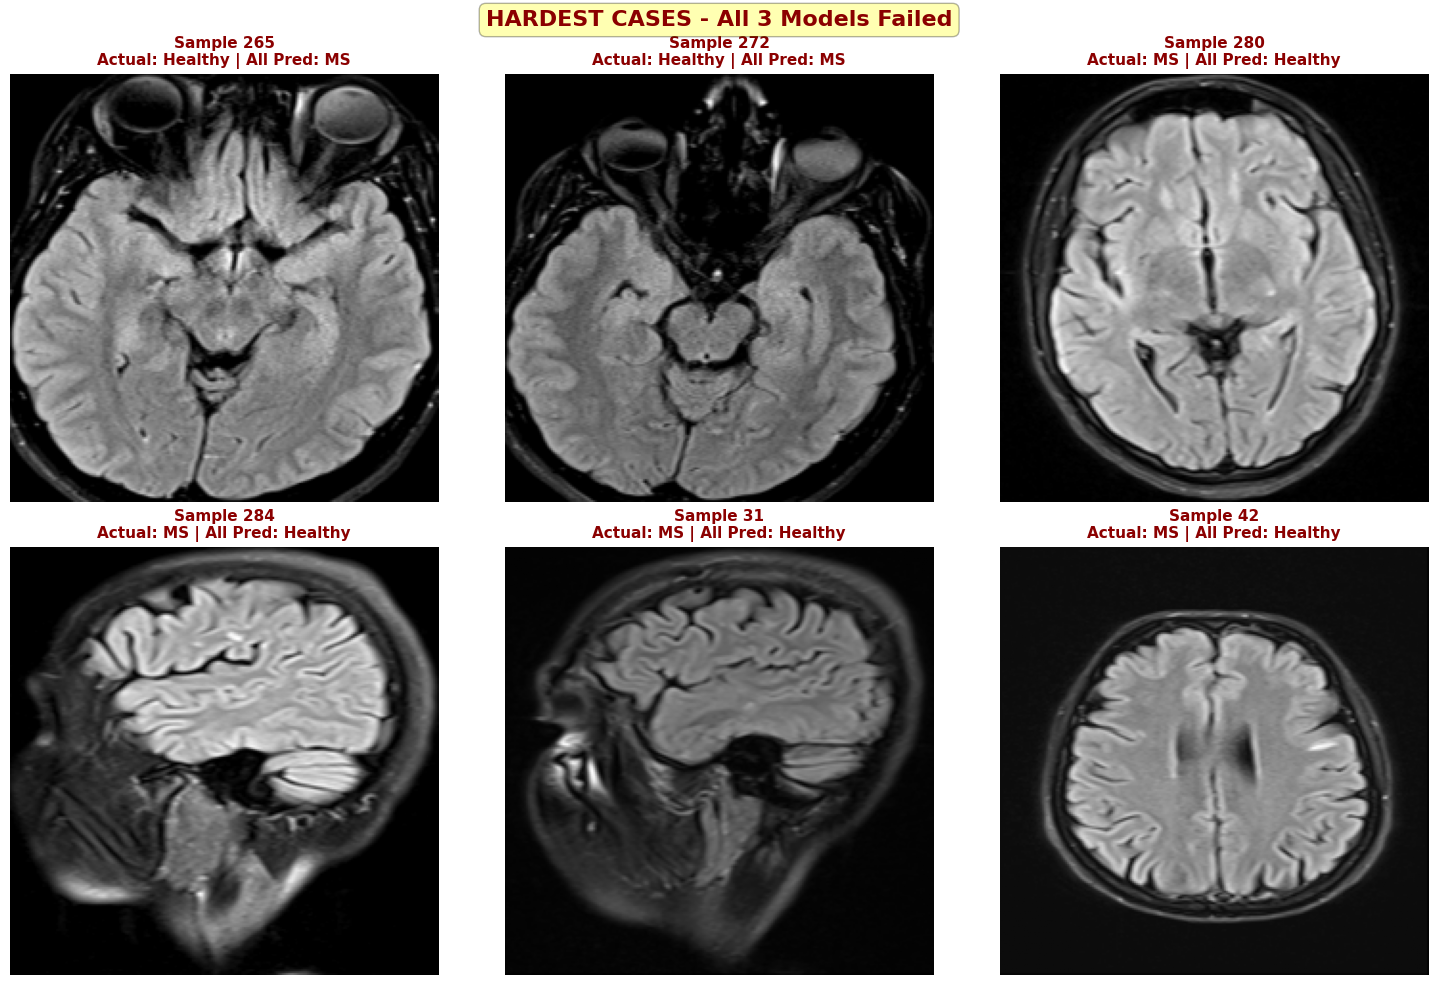

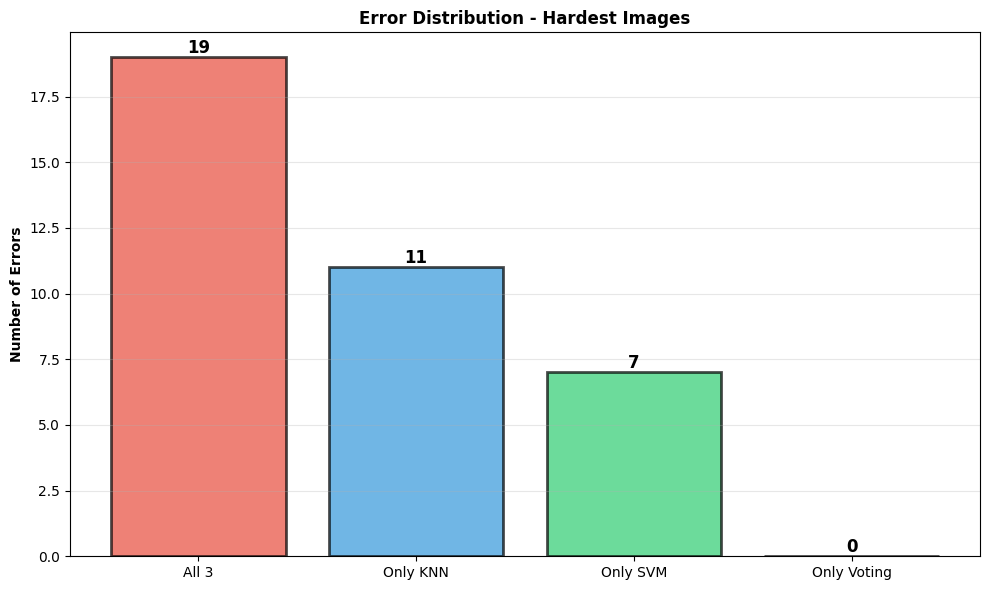

In [88]:
knn_errors = set(np.where(knn_best.predict(X_test) != y_test)[0])
svm_errors = set(np.where(svm_best.predict(X_test) != y_test)[0])
voting_errors = set(np.where(voting_clf.predict(X_test) != y_test)[0])

common_errors = knn_errors & svm_errors & voting_errors
knn_unique = knn_errors - svm_errors - voting_errors
svm_unique = svm_errors - knn_errors - voting_errors
voting_unique = voting_errors - knn_errors - svm_errors

print('='*80)
print('ERROR PATTERN ANALYSIS')
print('='*80)
print(f'\n Error Overlap:')
print(f'├─ All 3 wrong (hardest):  {len(common_errors):3d} images')
print(f'├─ Only KNN wrong:         {len(knn_unique):3d} images')
print(f'├─ Only SVM wrong:         {len(svm_unique):3d} images')
print(f'└─ Only Voting wrong:      {len(voting_unique):3d} images')
print('='*80)

if len(common_errors) > 0:
    print(f'\n Hardest cases (all failed)\n')
    common_list = list(common_errors)[:6]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('HARDEST CASES - All 3 Models Failed', fontsize=16, fontweight='bold', color='darkred',
                 bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    for i in range(6):
        ax = axes[i // 3, i % 3]
        if i < len(common_list):
            idx = common_list[i]
            img = X_test_original[idx].reshape(224, 224)
            actual = 'MS' if y_test[idx] == 1 else 'Healthy'
            predicted = 'MS' if knn_best.predict(X_test[idx].reshape(1, -1))[0] == 1 else 'Healthy'
            ax.imshow(img, cmap='gray')
            ax.set_title(f'Sample {idx}\nActual: {actual} | All Pred: {predicted}',
                       fontsize=11, color='darkred', fontweight='bold')
            ax.axis('off')
        else:
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Error distribution
categories = ['All 3', 'Only KNN', 'Only SVM', 'Only Voting']
counts = [len(common_errors), len(knn_unique), len(svm_unique), len(voting_unique)]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel('Number of Errors', fontweight='bold')
plt.title('Error Distribution - Hardest Images', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Save Models

In [89]:
if not os.path.exists('models'):
    os.makedirs('models')

with open('models/knn_model.pkl', 'wb') as f:
    pickle.dump(knn_best, f)
with open('models/svm_model.pkl', 'wb') as f:
    pickle.dump(svm_best, f)
with open('models/voting_model.pkl', 'wb') as f:
    pickle.dump(voting_clf, f)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('models/pca.pkl', 'wb') as f:
    pickle.dump(pca, f)

print('All models saved!')
print('\nSaved files:')
print('├─ models/knn_model.pkl')
print('├─ models/svm_model.pkl')
print('├─ models/voting_model.pkl')
print('├─ models/scaler.pkl')
print('└─ models/pca.pkl')

All models saved!

Saved files:
├─ models/knn_model.pkl
├─ models/svm_model.pkl
├─ models/voting_model.pkl
├─ models/scaler.pkl
└─ models/pca.pkl
